<a href="https://colab.research.google.com/github/AKBER-HUSSAIN/DL-2026/blob/main/week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implement Auto Encoder model on MINIST dataset.**


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3409 - val_loss: 0.2721
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2681 - val_loss: 0.2656
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2649 - val_loss: 0.2640
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2640 - val_loss: 0.2635
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2636 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2633 - val_loss: 0.2631
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2629 - val_loss: 0.2613
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2591 - val_loss: 0.2567
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2555 - val_loss: 0.2540
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2514 - val_loss: 0.2478
E

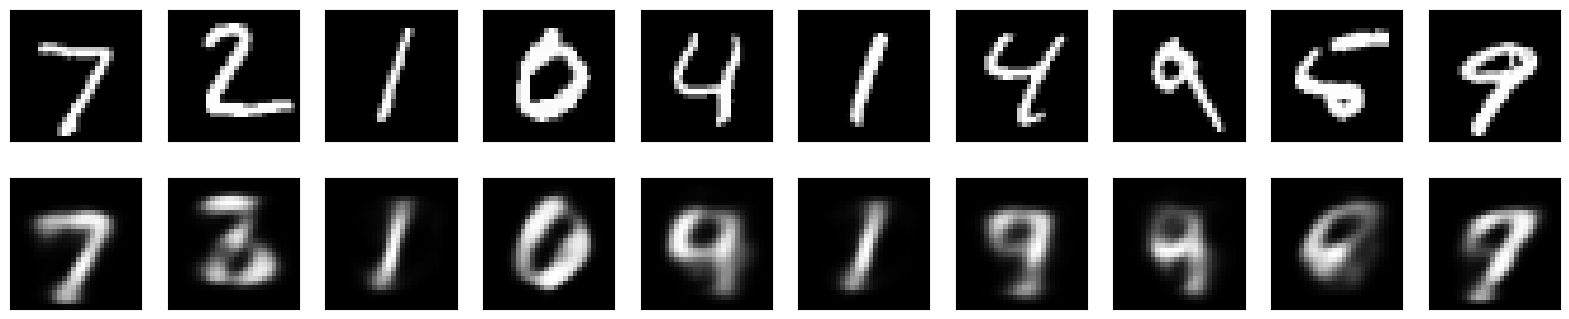

In [1]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))


input_dim = 784
encoding_dim = 31


input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)


decoded = Dense(input_dim, activation='sigmoid')(encoded)


autoencoder = Model(input_layer, decoded)


autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))



decoded_imgs = autoencoder.predict(x_test)


n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# AutoEncoder with Intermediate steps

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2421 - val_loss: 0.1570
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1410 - val_loss: 0.1256
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1176 - val_loss: 0.1080
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1039 - val_loss: 0.0974
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0948 - val_loss: 0.0901
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0885 - val_loss: 0.0850
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0841 - val_loss: 0.0816
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0811 - val_loss: 0.0791
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0790 - val_loss: 0.0774
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0776 - val_loss: 0.0762
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0765 - val_loss: 0.0754
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

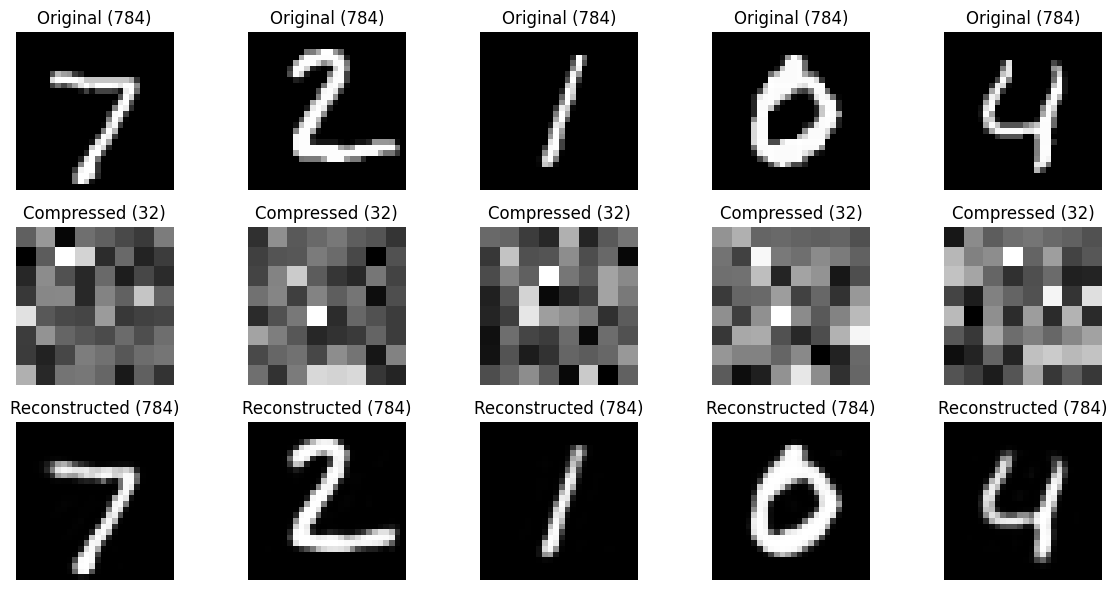

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.


x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


input_dim = 784
encoding_dim = 64


input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)


autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)


autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)


n = 5
plt.figure(figsize=(12, 6))

for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original (784)")
    plt.gray()
    ax.axis('off')

    # Encoded (32 → 4x8)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(8, 8))
    plt.title("Compressed (32)")
    plt.gray()
    ax.axis('off')

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed (784)")
    plt.gray()
    ax.axis('off')

plt.tight_layout()   #
plt.show()

# **Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)**



Training Autoencoder with dimension = 1024
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


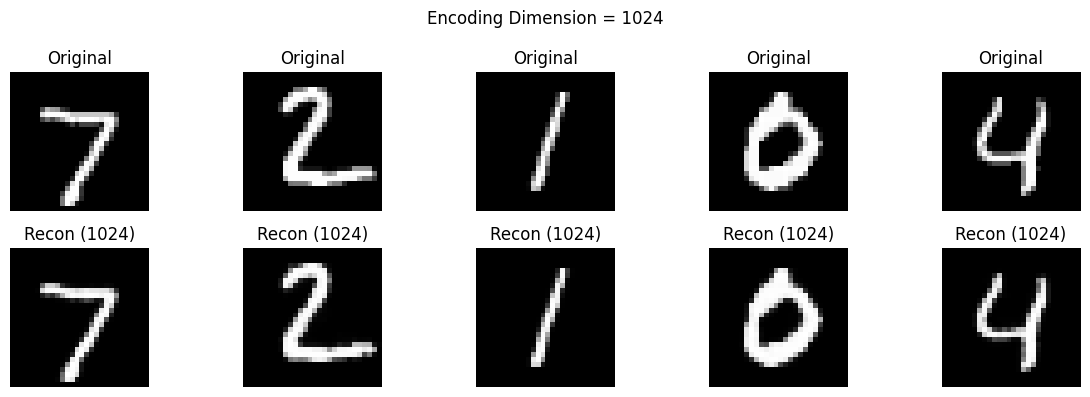


Training Autoencoder with dimension = 900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


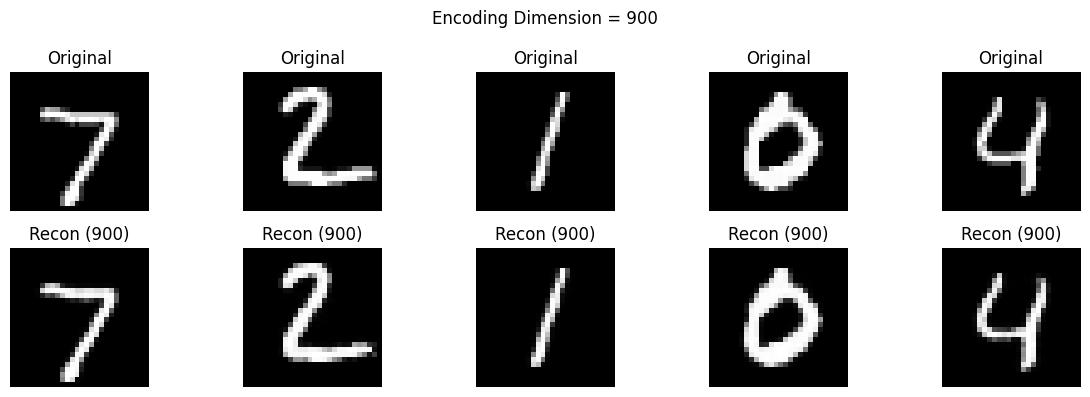


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


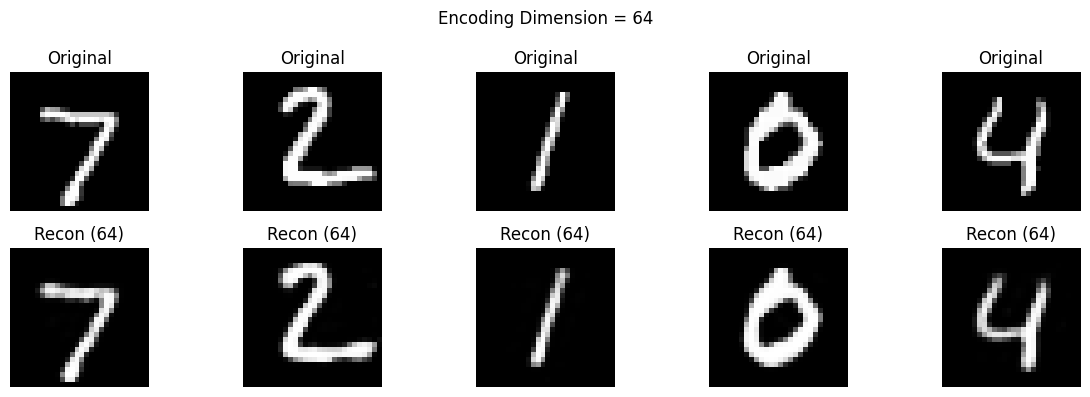


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


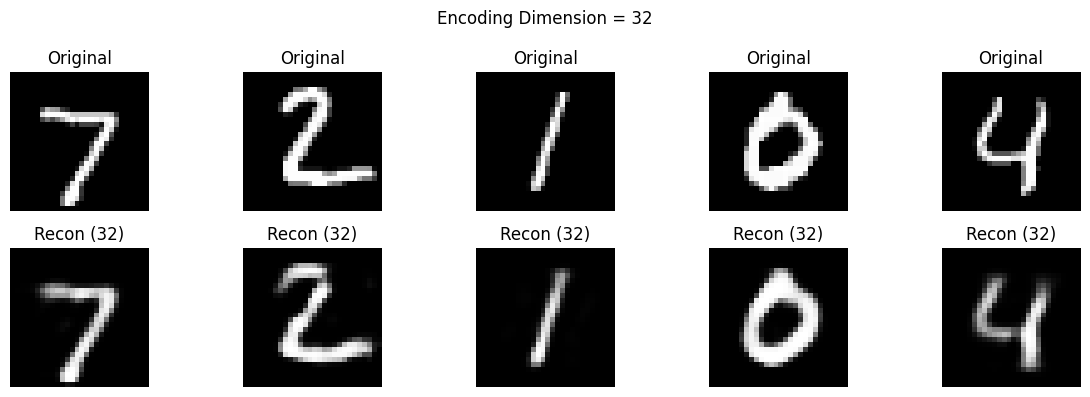


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


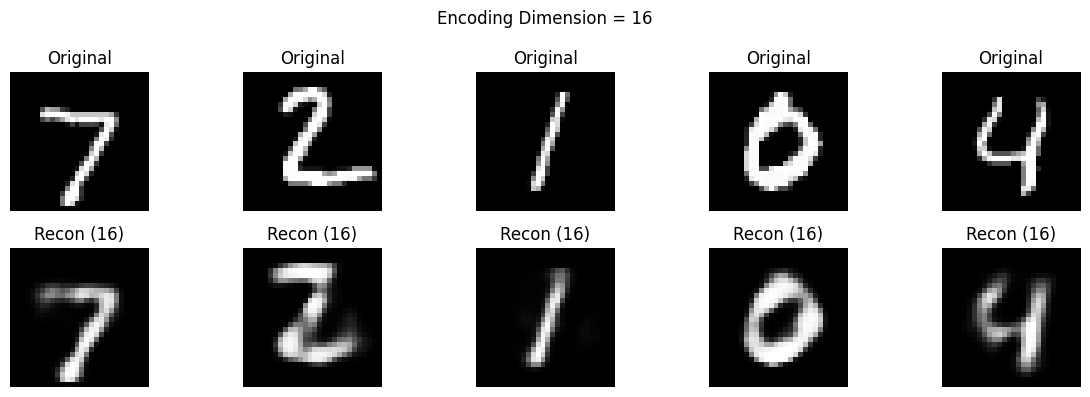


Training Autoencoder with dimension = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


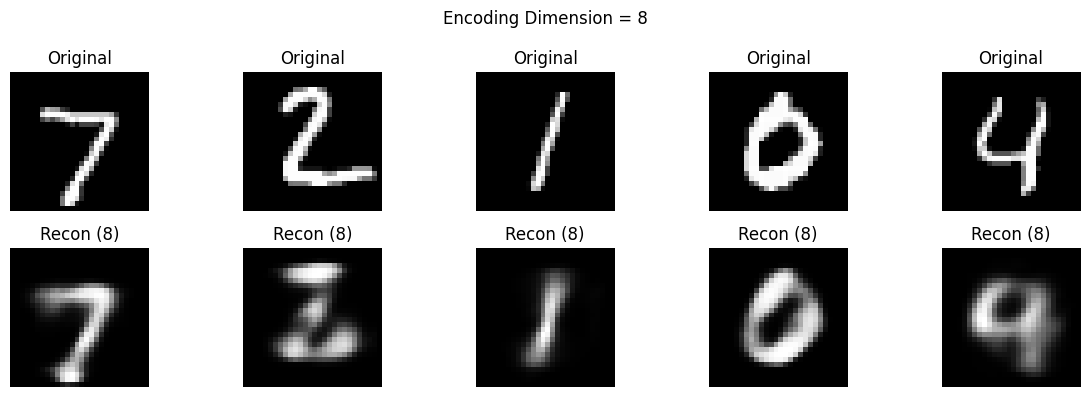


Training Autoencoder with dimension = 4
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


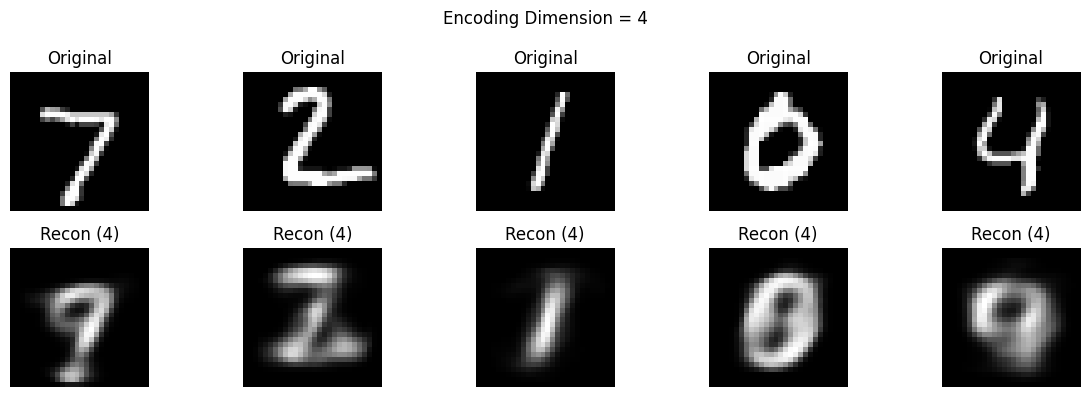


Training Autoencoder with dimension = 2
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


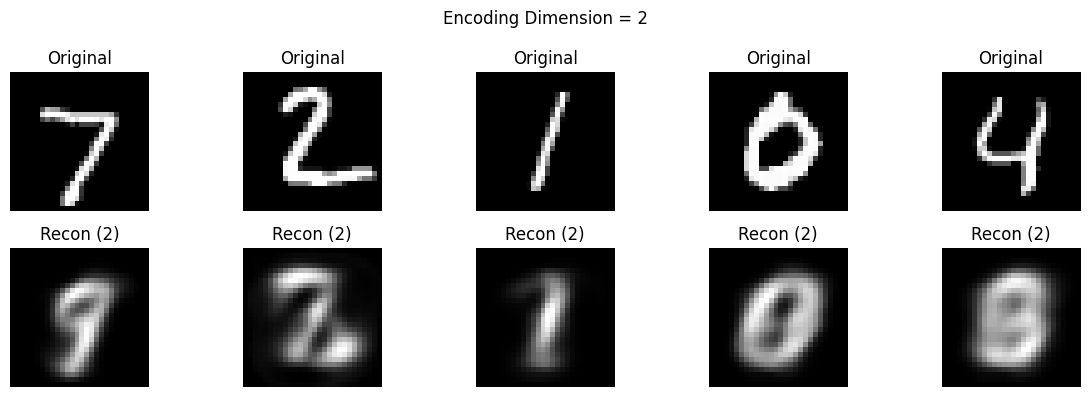


Training Autoencoder with dimension = 1
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


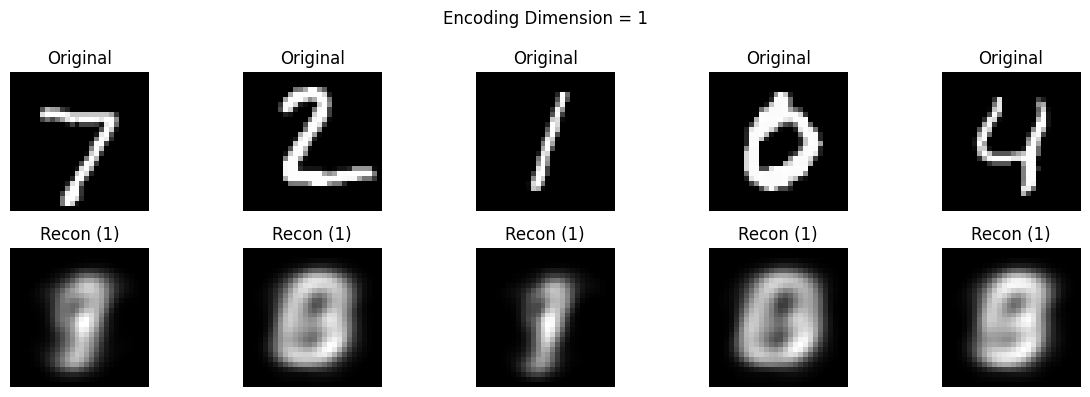

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


dimensions = [1024,900,64, 32, 16, 8, 4, 2, 1]


n = 5

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train (keep epochs small for speed)
    autoencoder.fit(x_train, x_train,
                    epochs=10,
                    batch_size=32,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    # Predict
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)


    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# **OBSERVATIONS**

1. Overcomplete autoencoder (1024, 900) produces almost identical output as input due to identity mapping.
2. No meaningful compression is achieved in overcomplete autoencoder without regularization.
3. Undercomplete autoencoder with 64 and 32 dimensions shows slight loss but images are clearly recognizable.
4. Dimensions 32–64 provide a good balance between compression and reconstruction quality.
5. When dimension is reduced below 32 (16, 8, etc.), images become blurry and lose important details.
6. Very low dimensions (≤8) result in poor reconstruction and unrecognizable images.
7. Lower dimension leads to higher compression but greater information loss.
8. Higher dimension leads to better reconstruction but less compression.

# Implement Regularization in AE and demonstrate its use.

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3972 - val_loss: 0.2736
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2448 - val_loss: 0.2271
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2198 - val_loss: 0.2121
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2083 - val_loss: 0.2034
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2007 - val_loss: 0.1968
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1945 - val_loss: 0.1912
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1893 - val_loss: 0.1865
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1852 - val_loss: 0.1829
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1818 - val_loss: 0.1797
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1789 - val_loss: 0.1770
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1765 - val_loss: 0.1747
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

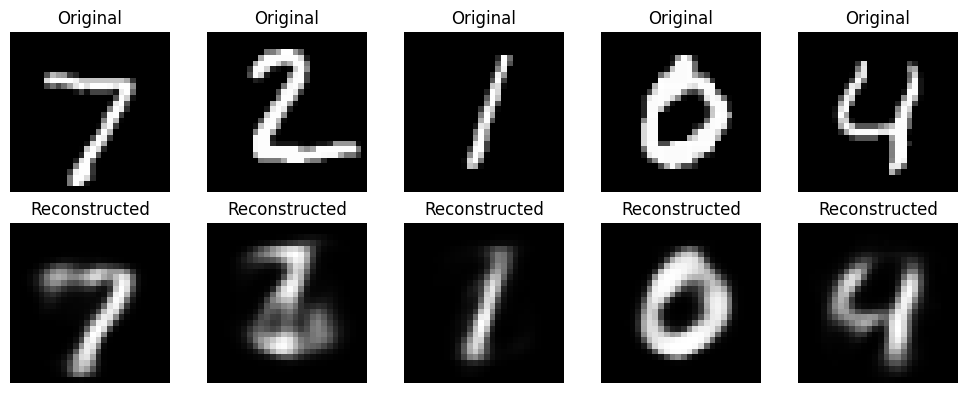

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


input_dim = 784
encoding_dim = 64


input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim,
                activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)


autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)


autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

# -----------------------------
# 9. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

# Epochs - 50 & le-5 as regularization strength

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4071 - val_loss: 0.2732
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2436 - val_loss: 0.2265
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2199 - val_loss: 0.2126
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2080 - val_loss: 0.2022
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1995 - val_loss: 0.1950
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1932 - val_loss: 0.1894
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1882 - val_loss: 0.1850
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1843 - val_loss: 0.1814
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1812 - val_loss: 0.1785
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1785 - val_loss: 0.1759
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1761 - val_loss: 0.1737
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

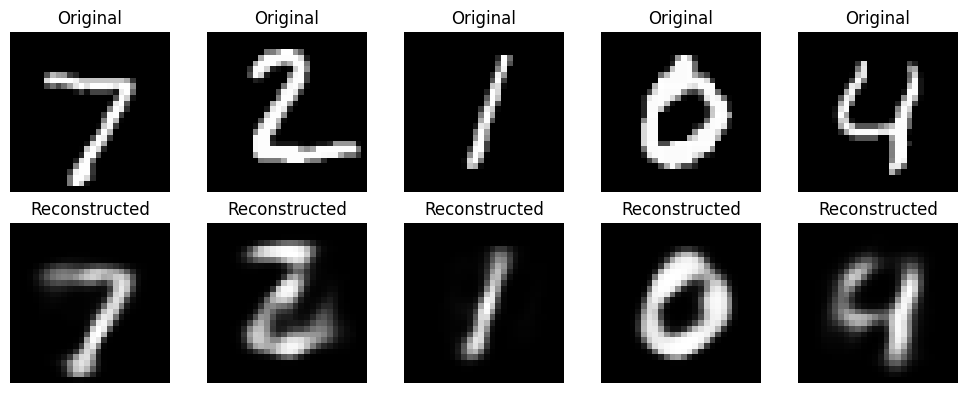

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


input_dim = 784
encoding_dim = 64


input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim,
                activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)


decoded = Dense(input_dim, activation='sigmoid')(encoded)


autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)


autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)


n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

# Epochs - 50 & le-6 as regu;arization strength

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2681 - val_loss: 0.1780
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1612 - val_loss: 0.1473
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1409 - val_loss: 0.1327
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1289 - val_loss: 0.1230
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1206 - val_loss: 0.1162
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1147 - val_loss: 0.1113
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1104 - val_loss: 0.1078
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1072 - val_loss: 0.1049
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1046 - val_loss: 0.1026
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1025 - val_loss: 0.1007
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1007 - val_loss: 0.0991
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

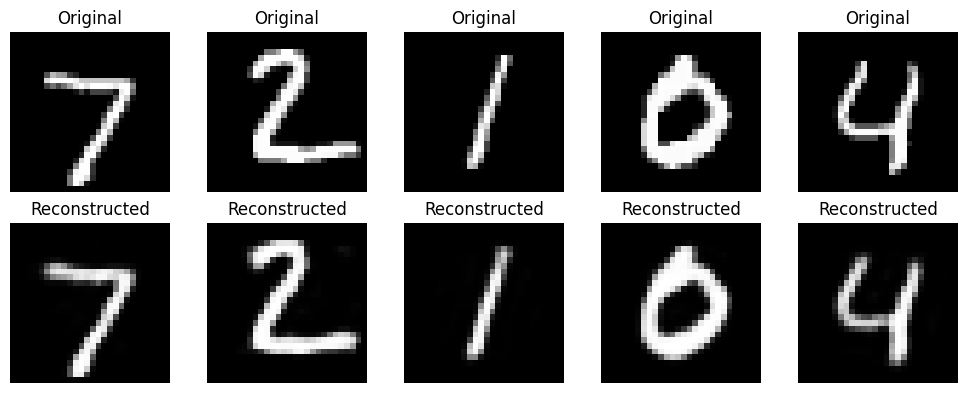

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


input_dim = 784
encoding_dim = 64

input_layer = Input(shape=(input_dim,))

encoded = Dense(encoding_dim,
                activation='relu',
                activity_regularizer=regularizers.l1(1e-6))(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)


autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)


autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)


n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

# **OBSERVATIONS**

1. Regularization introduces a penalty term in the loss function, controlling model complexity.
2. With strong regularization (e.g., L1 = 1e-5), many neurons become inactive, creating sparse representations.
3. Strong regularization reduces reconstruction quality, resulting in slightly blurred images.
4. Weak regularization (e.g., L1 = 1e-6) allows better reconstruction, producing clearer images.
5. Very weak or no regularization leads to near-perfect reconstruction due to identity mapping.
6. Regularization helps prevent overfitting by restricting unnecessary neuron activations.
7. It forces the model to learn important features instead of memorizing input data.
8. Strong regularization reduces the impact of encoding dimension, making outputs similar across different sizes.

# **Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)**


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2463 - val_loss: 0.1717
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1547 - val_loss: 0.1383
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1308 - val_loss: 0.1217
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1177 - val_loss: 0.1117
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1096 - val_loss: 0.1055
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1047 - val_loss: 0.1018
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1014 - val_loss: 0.0992
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0991 - val_loss: 0.0973
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0972 - val_loss: 0.0958
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0958 - val_loss: 0.0945
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0947 - val_loss: 0.0938
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

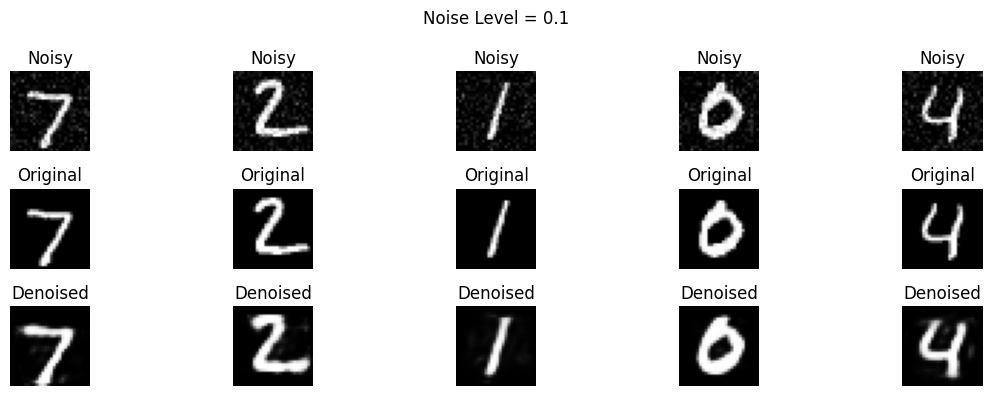


Testing with noise level = 0.3
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


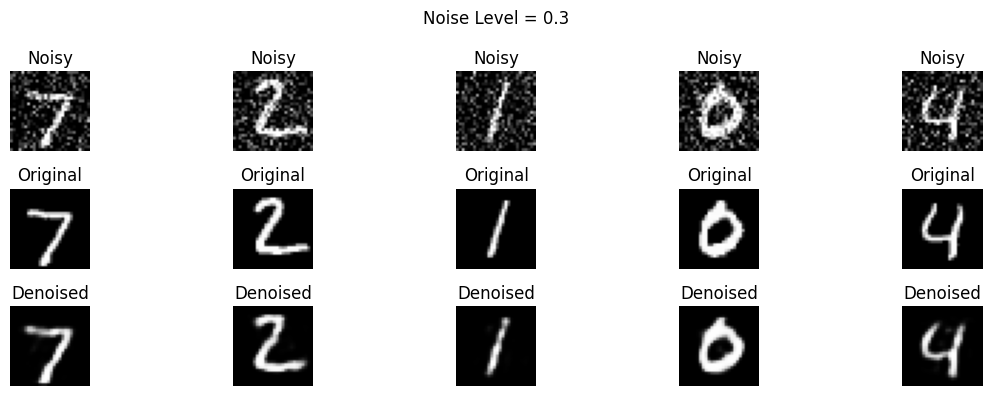


Testing with noise level = 0.5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


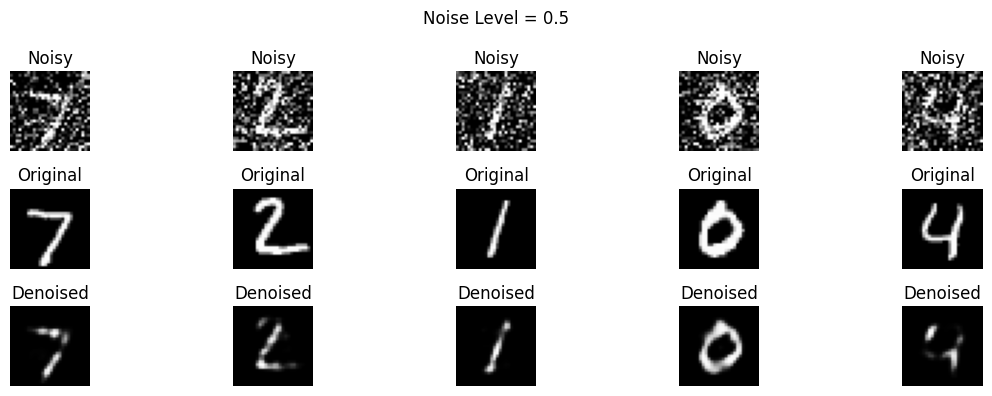

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


noise_factor = 0.3  # moderate noise

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))


noise_levels = [0.1, 0.3, 0.5]

n = 5

for noise in noise_levels:
    print(f"\nTesting with noise level = {noise}")

    x_test_noisy = x_test + noise * np.random.normal(size=x_test.shape)
    x_test_noisy = np.clip(x_test_noisy, 0., 1.)

    decoded_imgs = autoencoder.predict(x_test_noisy)


    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Noise Level = {noise}")

    for i in range(n):
        # Noisy Input
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i].reshape(28, 28))
        plt.title("Noisy")
        plt.gray()
        ax.axis('off')

        # Original Image
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')

        # Reconstructed Image
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title("Denoised")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# **OBSERVATIONS**
1. For low noise levels (0.1), the reconstructed images are almost identical to the original images.
2. For moderate noise levels (0.3), most noise is removed, but slight blurring is observed.
3. For high noise levels (0.5), reconstruction quality decreases and important details are lost.
4. As noise increases, the model struggles to recover fine features of the image.
5. Moderate noise levels help the model generalize better compared to very low noise.
6. Noise up to 0.1–0.3 is effectively removed with good reconstruction.
7. Noise beyond 0.5 significantly degrades image quality.